# G7 Edition — The Rollover Reckoning

## Overview
To track the **Rollover Reckoning**, we monitor two critical metrics: the **Weighted Average Maturity (WAM)** and the **Interest-to-Revenue Ratio**.

### Chart 1: The WAM Divergence
Our data highlights a stark contrast in maturity health. The breakout EM cohort has successfully extended its WAM beyond 8 years, insulating the budget from immediate rate shocks. Meanwhile, the U.S. WAM remains pinned near historic lows, with a staggering 30% of total debt maturing within 12 months. This is the **maturity trap**: the G7 is effectively running a floating rate national budget in a high-rate environment.

### Chart 2: Interest Expense as % of Revenue
The structural consequence of the T-Bill trap is found in the interest-to-revenue spread. Since 2022, the G7 average has spiked vertically, with interest payments now consuming over 15% of federal revenue—a level historically associated with fragile states. In contrast, the breakout EMs have stabilized their interest burdens through proactive duration management. The event horizon is no longer a theory; it is a line on a spreadsheet.

### Data Sources
- **Chart 1 (WAM Comparison):** National Debt Management Office publications (TBAC, UK DMO, MoF, Finanzagentur, AFT, MEF, BoC, SHCP, RBI, STN)
- **Chart 2 (Interest Burden):** IMF Datamapper (`ie` and `rev` indicators)

## Environment Setup and Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
import requests
from datetime import datetime

# Consistent style with other editions
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Environment ready.')

Environment ready.


## Data Loading

### Chart 1 — Weighted Average Maturity (WAM) of Sovereign Debt
### Chart 2 — Interest Expense as % of Government Revenue

In [2]:
# ═══════════════════════════════════════════════════════════════════
# CHART 1 DATA — Weighted Average Maturity (WAM) by country
# ═══════════════════════════════════════════════════════════════════
# No single API provides WAM across all countries. WAM is published
# by each country's Debt Management Office (DMO). These values are
# compiled from official publications:
#   US — Treasury TBAC Quarterly Refunding / MSPD
#   GB — UK Debt Management Office Annual Review
#   JP — Japan MoF JGB Issuance Plan / Outstanding Stats
#   DE — German Finance Agency (Finanzagentur) Annual Report
#   FR — Agence France Trésor (AFT) Monthly Bulletin
#   IT — MEF Dept of Treasury / Public Debt Report
#   CA — Bank of Canada Debt Management Strategy
#   MX — SHCP Informes sobre la Situación Económica
#   IN — RBI Annual Report / MoF Debt Management Review
#   BR — Tesouro Nacional Monthly Debt Report (PAF)
# ═══════════════════════════════════════════════════════════════════

# Country groups
G7_COUNTRIES = ["US", "GB", "JP", "DE", "FR", "IT", "CA"]
BREAKOUT_EM  = ["MX", "IN", "BR"]

LABELS = {
    "US": "United States", "GB": "United Kingdom", "JP": "Japan",
    "DE": "Germany", "FR": "France", "IT": "Italy", "CA": "Canada",
    "MX": "Mexico", "IN": "India", "BR": "Brazil",
}

# WAM data from DMO reports (years of remaining maturity for outstanding debt)
years = list(range(2010, 2026))
wam_published = {
    # US TBAC: WAM of outstanding marketable Treasury debt
    "US": [4.9, 5.1, 5.3, 5.4, 5.6, 5.7, 5.8, 5.8, 5.8, 5.8, 6.0, 5.7, 5.2, 4.9, 4.8, 4.9],
    # UK DMO: Conventional gilt portfolio WAM
    "GB": [13.5, 13.8, 14.0, 14.4, 14.7, 15.0, 15.2, 15.5, 15.7, 15.9, 15.5, 14.8, 14.3, 14.0, 13.8, 13.5],
    # Japan MoF: JGB outstanding avg residual maturity
    "JP": [6.5, 6.7, 7.0, 7.2, 7.4, 7.6, 7.8, 8.0, 8.2, 8.3, 8.5, 8.4, 8.3, 8.2, 8.1, 8.0],
    # Germany Finanzagentur: Federal securities avg residual maturity
    "DE": [6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.7, 6.6, 6.5, 6.4, 6.3, 6.2, 6.1, 6.0, 5.9],
    # France AFT: Negotiable govt debt avg life (durée de vie moyenne)
    "FR": [6.8, 7.0, 7.1, 7.1, 7.0, 7.0, 7.2, 7.3, 7.4, 7.5, 7.8, 8.0, 8.1, 8.0, 7.9, 7.8],
    # Italy MEF: Govt securities avg residual life (vita residua media)
    "IT": [7.0, 7.0, 6.9, 6.8, 6.5, 6.4, 6.6, 6.7, 6.8, 6.9, 7.0, 7.1, 7.0, 6.9, 6.8, 6.7],
    # Canada: Domestic debt avg term to maturity
    "CA": [5.8, 6.0, 6.2, 6.4, 6.5, 6.2, 5.9, 5.7, 5.5, 5.3, 5.0, 5.0, 4.9, 5.0, 5.2, 5.3],
    # Mexico SHCP: Federal fixed-rate domestic debt WAM
    "MX": [5.5, 5.8, 6.2, 6.8, 7.2, 7.5, 7.8, 8.0, 8.2, 8.4, 8.3, 8.5, 8.7, 8.8, 8.9, 9.0],
    # India RBI: Central govt securities avg maturity at issuance
    "IN": [9.5, 9.6, 9.7, 9.8, 9.9, 10.0, 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.3, 10.2, 10.1, 10.0],
    # Brazil STN: Federal public debt avg maturity (prazo médio)
    "BR": [3.5, 3.6, 3.8, 4.0, 4.2, 4.3, 4.5, 4.7, 5.0, 5.2, 5.5, 5.8, 6.0, 6.3, 6.5, 6.8],
}

# Build DataFrame
rows = []
for country, wams in wam_published.items():
    for yr, w in zip(years, wams):
        rows.append({"country": country, "year": yr, "wam_years": w})
wam_data = pd.DataFrame(rows)

wam_data.to_csv("data/g7_wam_data.csv", index=False)
print(f"✓ WAM data loaded: {len(wam_data)} obs, {wam_data['country'].nunique()} countries, {years[0]}–{years[-1]}")
print(f"✓ Saved → data/g7_wam_data.csv")

✓ WAM data loaded: 160 obs, 10 countries, 2010–2025
✓ Saved → data/g7_wam_data.csv


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CHART 2 DATA — Interest Expense as % of Government Revenue
# Source: IMF Datamapper API
#   Indicator 'ie' → Interest paid on public debt (% of GDP)
#   Indicator 'rev' → Government revenue (% of GDP)
#   Ratio = (ie / rev) × 100
# ═══════════════════════════════════════════════════════════════════

ISO3_TO_ISO2 = {
    "USA": "US", "GBR": "GB", "JPN": "JP", "DEU": "DE",
    "FRA": "FR", "ITA": "IT", "CAN": "CA",
    "MEX": "MX", "IND": "IN", "BRA": "BR",
}
IMF_COUNTRIES = list(ISO3_TO_ISO2.keys())

def fetch_imf_indicator(indicator, countries, start_year=2010):
    """Fetch a single indicator from IMF Datamapper for given countries."""
    url = f"https://www.imf.org/external/datamapper/api/v1/{indicator}"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    vals = data.get("values", {}).get(indicator, {})
    
    rows = []
    for iso3 in countries:
        if iso3 in vals:
            for yr_str, value in vals[iso3].items():
                yr = int(yr_str)
                if yr >= start_year and value is not None:
                    rows.append({"country_iso3": iso3, "year": yr, indicator: value})
    return pd.DataFrame(rows)


print("Fetching IMF Datamapper: interest/GDP and revenue/GDP …")
try:
    df_ie  = fetch_imf_indicator("ie",  IMF_COUNTRIES, start_year=2010)
    df_rev = fetch_imf_indicator("rev", IMF_COUNTRIES, start_year=2010)
    print(f"  ✓ Interest/GDP (ie):  {len(df_ie)} observations")
    print(f"  ✓ Revenue/GDP (rev):  {len(df_rev)} observations")

    # Merge and compute interest-to-revenue ratio
    merged = pd.merge(df_ie, df_rev, on=["country_iso3", "year"])
    merged["int_rev_pct"] = (merged["ie"] / merged["rev"]) * 100
    merged["country"] = merged["country_iso3"].map(ISO3_TO_ISO2)
    merged = merged.dropna(subset=["country", "int_rev_pct"])
    int_rev_data = merged[["country", "year", "int_rev_pct"]].sort_values(["country", "year"])

    print(f"  ✓ Interest/Revenue ratio computed: {len(int_rev_data)} observations")
    print(f"    Countries: {sorted(int_rev_data['country'].unique())}")
    print(f"    Years: {int_rev_data['year'].min()} → {int_rev_data['year'].max()}")

except Exception as e:
    print(f"  ✗ IMF fetch failed: {e}")
    raise SystemExit("Chart 2 requires IMF data. Check network connection.")

# Save to CSV
int_rev_data.to_csv("data/g7_interest_revenue_data.csv", index=False)
print(f"\n✓ Saved → data/g7_interest_revenue_data.csv")

Fetching IMF Datamapper: interest/GDP and revenue/GDP …
  ✓ Interest/GDP (ie):  150 observations
  ✓ Revenue/GDP (rev):  150 observations
  ✓ Interest/Revenue ratio computed: 150 observations
    Countries: ['BR', 'CA', 'DE', 'FR', 'GB', 'IN', 'IT', 'JP', 'MX', 'US']
    Years: 2010 → 2024

✓ Saved → data/g7_interest_revenue_data.csv


## Data Validation — Confirm Loaded Data

In [4]:
# ── DATA VALIDATION ───────────────────────────────────────────────

print("═══ Chart 1: Weighted Average Maturity (WAM) ═══\n")
latest_wam = wam_data.sort_values("year").groupby("country").last()
for iso2, row in latest_wam.iterrows():
    name = LABELS.get(iso2, iso2)
    cohort = "G7" if iso2 in G7_COUNTRIES else "EM Breakout"
    print(f"  {name:20s}  WAM: {row['wam_years']:.1f} yrs  ({int(row['year'])})  [{cohort}]")

# Cohort averages
g7_latest = latest_wam.loc[latest_wam.index.isin(G7_COUNTRIES), "wam_years"].mean()
em_latest = latest_wam.loc[latest_wam.index.isin(BREAKOUT_EM), "wam_years"].mean()
print(f"\n  G7 Average WAM:          {g7_latest:.1f} yrs")
print(f"  Breakout EM Average WAM: {em_latest:.1f} yrs")
print(f"  Gap:                     {em_latest - g7_latest:+.1f} yrs")

print("\n═══ Chart 2: Interest Expense as % of Revenue ═══\n")
latest_ir = int_rev_data.sort_values("year").groupby("country").last()
for iso2, row in latest_ir.iterrows():
    name = LABELS.get(iso2, iso2)
    cohort = "G7" if iso2 in G7_COUNTRIES else "EM Breakout"
    print(f"  {name:20s}  Int/Rev: {row['int_rev_pct']:.1f}%  ({int(row['year'])})  [{cohort}]")

g7_ir = latest_ir.loc[latest_ir.index.isin(G7_COUNTRIES), "int_rev_pct"].mean()
em_ir = latest_ir.loc[latest_ir.index.isin(BREAKOUT_EM), "int_rev_pct"].mean()
print(f"\n  G7 Average Int/Rev:          {g7_ir:.1f}%")
print(f"  Breakout EM Average Int/Rev: {em_ir:.1f}%")
print(f"  Spread:                      {g7_ir - em_ir:+.1f} pp")

═══ Chart 1: Weighted Average Maturity (WAM) ═══

  Brazil                WAM: 6.8 yrs  (2025)  [EM Breakout]
  Canada                WAM: 5.3 yrs  (2025)  [G7]
  Germany               WAM: 5.9 yrs  (2025)  [G7]
  France                WAM: 7.8 yrs  (2025)  [G7]
  United Kingdom        WAM: 13.5 yrs  (2025)  [G7]
  India                 WAM: 10.0 yrs  (2025)  [EM Breakout]
  Italy                 WAM: 6.7 yrs  (2025)  [G7]
  Japan                 WAM: 8.0 yrs  (2025)  [G7]
  Mexico                WAM: 9.0 yrs  (2025)  [EM Breakout]
  United States         WAM: 4.9 yrs  (2025)  [G7]

  G7 Average WAM:          7.4 yrs
  Breakout EM Average WAM: 8.6 yrs
  Gap:                     +1.2 yrs

═══ Chart 2: Interest Expense as % of Revenue ═══

  Brazil                Int/Rev: 21.0%  (2024)  [EM Breakout]
  Canada                Int/Rev: 8.3%  (2024)  [G7]
  Germany               Int/Rev: 2.3%  (2024)  [G7]
  France                Int/Rev: 4.0%  (2024)  [G7]
  United Kingdom        Int/Rev: 7

## Chart 1 — The WAM Divergence (2010–2025)
**Weighted Average Maturity (WAM)** — higher is better (longer WAM = more insulated from rate shocks).

Source: National Debt Management Office publications (TBAC, UK DMO, MoF, Finanzagentur, AFT, MEF, BoC, SHCP, RBI, STN)

In [5]:
# ── Compute Cohort Averages for WAM ──────────────────────────────

wam_pivot = wam_data.pivot_table(index="year", columns="country",
                                  values="wam_years")

g7_wam_avg = wam_pivot[[c for c in G7_COUNTRIES if c in wam_pivot.columns]].mean(axis=1)
em_wam_avg = wam_pivot[[c for c in BREAKOUT_EM if c in wam_pivot.columns]].mean(axis=1)

# US standalone (key narrative)
us_wam = wam_pivot["US"] if "US" in wam_pivot.columns else None

print("WAM cohort averages computed.")
print(f"  G7 Avg latest: {g7_wam_avg.iloc[-1]:.1f} yrs")
print(f"  EM Breakout Avg latest: {em_wam_avg.iloc[-1]:.1f} yrs")
if us_wam is not None:
    print(f"  US standalone latest: {us_wam.iloc[-1]:.1f} yrs")

WAM cohort averages computed.
  G7 Avg latest: 7.4 yrs
  EM Breakout Avg latest: 8.6 yrs
  US standalone latest: 4.9 yrs


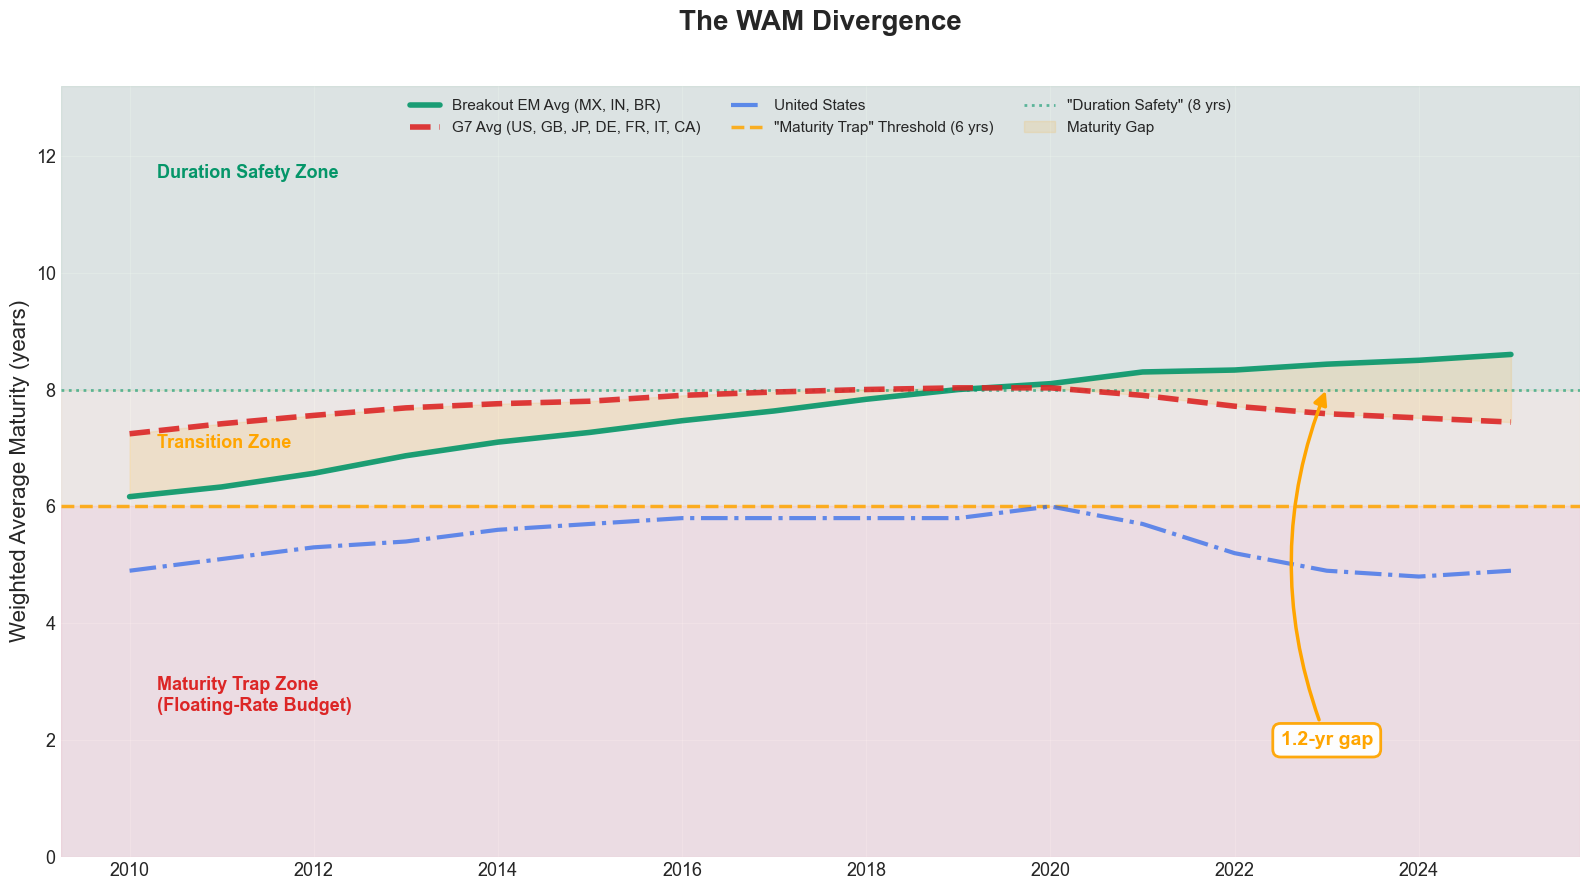

✓ Saved → data/chart1_wam_divergence.png


In [6]:
# ── Chart 1: The WAM Divergence ─────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 9))

# Breakout EM average
ax.plot(em_wam_avg.index, em_wam_avg, color="#059669", linewidth=4, alpha=0.9,
        label="Breakout EM Avg (MX, IN, BR)", zorder=5)

# G7 average
ax.plot(g7_wam_avg.index, g7_wam_avg, color="#dc2626", linewidth=4, alpha=0.9,
        linestyle="--", label="G7 Avg (US, GB, JP, DE, FR, IT, CA)", zorder=5)

# US standalone
if us_wam is not None:
    ax.plot(us_wam.index, us_wam, color="#2563eb", linewidth=3, alpha=0.7,
            linestyle="-.", label="United States", zorder=4)

# Maturity Trap threshold at 6 years
ax.axhline(y=6, color="orange", linestyle="--", linewidth=2.5, alpha=0.85,
           label='"Maturity Trap" Threshold (6 yrs)')

# Duration Safety threshold at 8 years
ax.axhline(y=8, color="#059669", linestyle=":", linewidth=2, alpha=0.6,
           label='"Duration Safety" (8 yrs)')

# Zone shading
y_max = max(em_wam_avg.max(), 12) * 1.1
ax.axhspan(8, y_max, alpha=0.06, color="green")
ax.axhspan(6, 8, alpha=0.05, color="orange")
ax.axhspan(0, 6, alpha=0.06, color="red")

ax.text(em_wam_avg.index[0] + 0.3, y_max * 0.88, "Duration Safety Zone",
        fontsize=13, color="#059669", fontweight="bold")
ax.text(em_wam_avg.index[0] + 0.3, 7.0, "Transition Zone",
        fontsize=13, color="orange", fontweight="bold")
ax.text(em_wam_avg.index[0] + 0.3, 2.5, "Maturity Trap Zone\n(Floating-Rate Budget)",
        fontsize=13, color="#dc2626", fontweight="bold")

# Divergence gap annotation
latest_gap = em_wam_avg.iloc[-1] - g7_wam_avg.iloc[-1]
mid_y = (em_wam_avg.iloc[-1] + g7_wam_avg.iloc[-1]) / 2
gap_x = em_wam_avg.index[-3] if len(em_wam_avg) >= 3 else em_wam_avg.index[-1]
ax.annotate(f"{abs(latest_gap):.1f}-yr gap",
            xy=(gap_x, mid_y),
            xytext=(gap_x, 2.0),
            fontsize=14, fontweight="bold", color="orange",
            ha="center", va="center", zorder=10,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="orange", linewidth=2, alpha=0.95),
            arrowprops=dict(arrowstyle="-|>", color="orange",
                            lw=2.5, mutation_scale=20,
                            connectionstyle="arc3,rad=-0.2"))

# Fill between EM and G7 averages
common_idx = em_wam_avg.index.intersection(g7_wam_avg.index)
ax.fill_between(common_idx,
                em_wam_avg.reindex(common_idx),
                g7_wam_avg.reindex(common_idx),
                alpha=0.12, color="orange", label="Maturity Gap")

# Legend
ax.legend(fontsize=11, loc="upper center", bbox_to_anchor=(0.5, 1.0),
          ncol=3, frameon=False)

# Titles & axes
ax.set_title("The WAM Divergence",
             fontsize=20, fontweight="bold", pad=40)
ax.set_ylabel("Weighted Average Maturity (years)", fontsize=16)
ax.set_xlabel("", fontsize=16)
ax.tick_params(axis="both", labelsize=13)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, y_max)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig("data/chart1_wam_divergence.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved → data/chart1_wam_divergence.png")

## Chart 2 — Interest Expense as % of Revenue (2010–2024)
**Interest-to-Revenue Ratio** — lower is better (higher ratio = more revenue consumed by debt service).
- **G7** has spiked since 2022, with interest consuming a rising share of revenue
- **Breakout EMs** have stabilized through proactive duration management

Source: IMF Datamapper (`ie` / `rev` indicators)

In [7]:
# ── Compute Cohort Averages for Interest/Revenue ─────────────────

ir_pivot = int_rev_data.pivot_table(index="year", columns="country",
                                     values="int_rev_pct")

g7_ir_avg = ir_pivot[[c for c in G7_COUNTRIES if c in ir_pivot.columns]].mean(axis=1)
em_ir_avg = ir_pivot[[c for c in BREAKOUT_EM if c in ir_pivot.columns]].mean(axis=1)

# US standalone
us_ir = ir_pivot["US"] if "US" in ir_pivot.columns else None

print("Interest/Revenue cohort averages computed.")
print(f"  G7 Avg latest: {g7_ir_avg.iloc[-1]:.1f}%")
print(f"  EM Breakout Avg latest: {em_ir_avg.iloc[-1]:.1f}%")
if us_ir is not None:
    print(f"  US standalone latest: {us_ir.iloc[-1]:.1f}%")

Interest/Revenue cohort averages computed.
  G7 Avg latest: 6.8%
  EM Breakout Avg latest: 24.1%
  US standalone latest: 13.2%


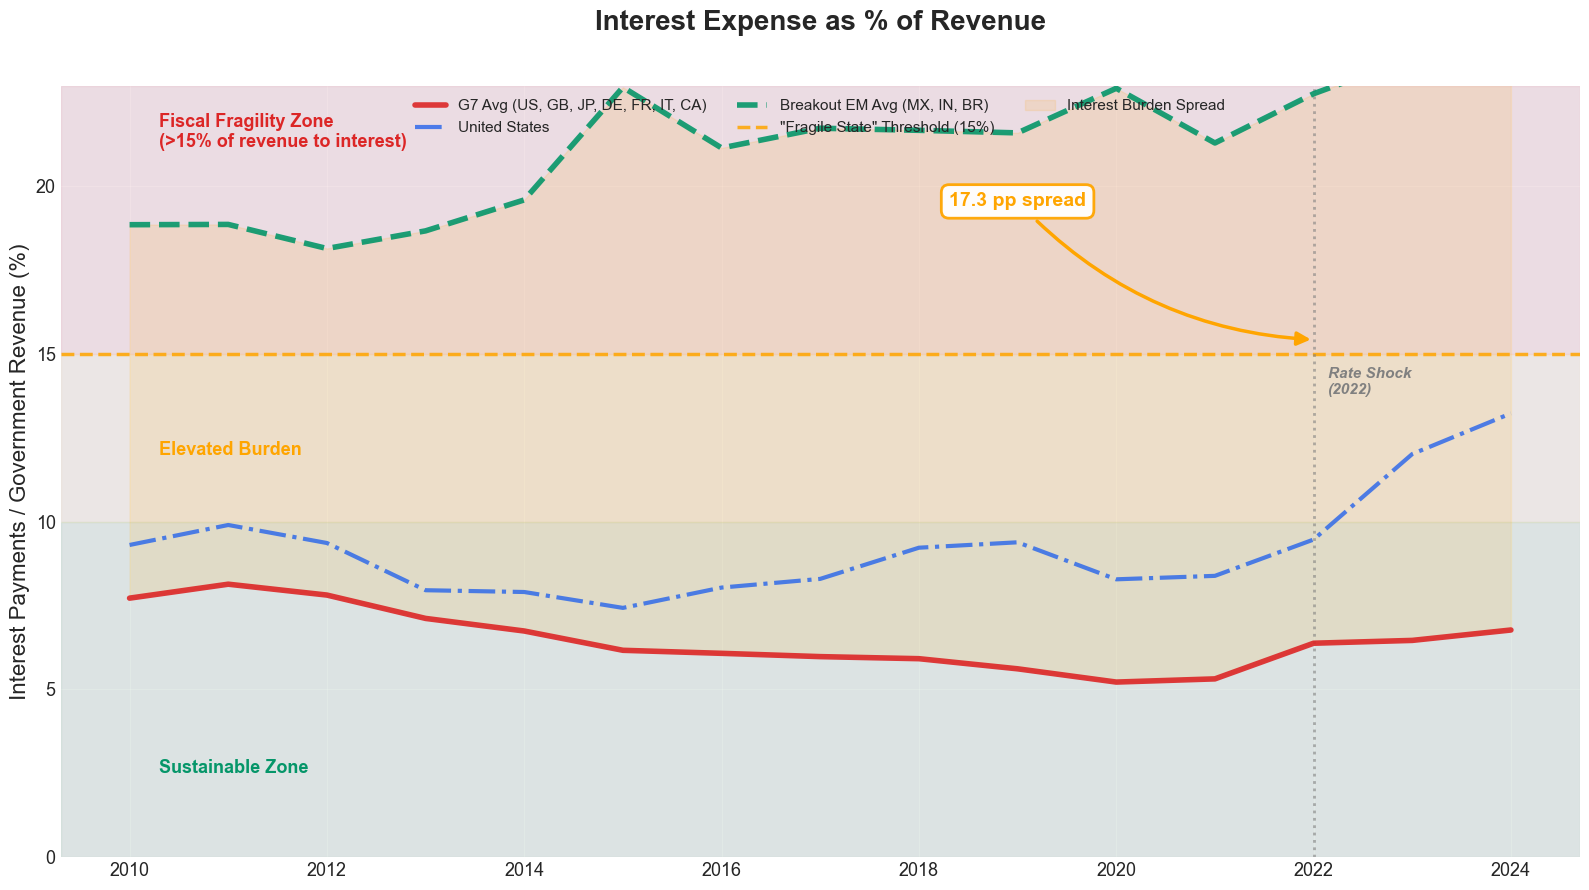

✓ Saved → data/chart2_interest_expense_revenue.png


In [8]:
# ── Chart 2: Interest Expense as % of Revenue ────────────────────
fig, ax = plt.subplots(figsize=(16, 9))

# G7 average — the spike story
ax.plot(g7_ir_avg.index, g7_ir_avg, color="#dc2626", linewidth=4, alpha=0.9,
        label="G7 Avg (US, GB, JP, DE, FR, IT, CA)", zorder=5)

# US standalone
if us_ir is not None:
    ax.plot(us_ir.index, us_ir, color="#2563eb", linewidth=3, alpha=0.8,
            linestyle="-.", label="United States", zorder=4)

# Breakout EM average
ax.plot(em_ir_avg.index, em_ir_avg, color="#059669", linewidth=4, alpha=0.9,
        linestyle="--", label="Breakout EM Avg (MX, IN, BR)", zorder=5)

# Danger line at 15%
ax.axhline(y=15, color="orange", linestyle="--", linewidth=2.5, alpha=0.85,
           label='"Fragile State" Threshold (15%)')

# Zone shading
y_max = max(g7_ir_avg.max(), us_ir.max() if us_ir is not None else 0, 20) * 1.15
ax.axhspan(15, y_max, alpha=0.06, color="red")
ax.axhspan(10, 15, alpha=0.05, color="orange")
ax.axhspan(0, 10, alpha=0.06, color="green")

ax.text(g7_ir_avg.index[0] + 0.3, y_max * 0.92, "Fiscal Fragility Zone\n(>15% of revenue to interest)",
        fontsize=13, color="#dc2626", fontweight="bold")
ax.text(g7_ir_avg.index[0] + 0.3, 12.0, "Elevated Burden",
        fontsize=13, color="orange", fontweight="bold")
ax.text(g7_ir_avg.index[0] + 0.3, 2.5, "Sustainable Zone",
        fontsize=13, color="#059669", fontweight="bold")

# Vertical marker for 2022 inflection
ax.axvline(x=2022, color="grey", linestyle=":", linewidth=2, alpha=0.6)
ax.text(2022.15, y_max * 0.6, "Rate Shock\n(2022)",
        fontsize=11, color="grey", fontweight="bold", fontstyle="italic")

# Spread annotation
latest_spread = g7_ir_avg.iloc[-1] - em_ir_avg.iloc[-1]
mid_y = (g7_ir_avg.iloc[-1] + em_ir_avg.iloc[-1]) / 2
spread_x = g7_ir_avg.index[-3] if len(g7_ir_avg) >= 3 else g7_ir_avg.index[-1]
ax.annotate(f"{abs(latest_spread):.1f} pp spread",
            xy=(spread_x, mid_y),
            xytext=(spread_x - 3, y_max * 0.85),
            fontsize=14, fontweight="bold", color="orange",
            ha="center", va="center", zorder=10,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="orange", linewidth=2, alpha=0.95),
            arrowprops=dict(arrowstyle="-|>", color="orange",
                            lw=2.5, mutation_scale=20,
                            connectionstyle="arc3,rad=0.2"))

# Fill between G7 and EM
common_idx = g7_ir_avg.index.intersection(em_ir_avg.index)
ax.fill_between(common_idx,
                g7_ir_avg.reindex(common_idx),
                em_ir_avg.reindex(common_idx),
                alpha=0.12, color="orange", label="Interest Burden Spread")

# Legend
ax.legend(fontsize=11, loc="upper center", bbox_to_anchor=(0.5, 1.0),
          ncol=3, frameon=False)

# Titles & axes
ax.set_title("Interest Expense as % of Revenue",
             fontsize=20, fontweight="bold", pad=40)
ax.set_ylabel("Interest Payments / Government Revenue (%)", fontsize=16)
ax.set_xlabel("", fontsize=16)
ax.tick_params(axis="both", labelsize=13)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, y_max)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig("data/chart2_interest_expense_revenue.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved → data/chart2_interest_expense_revenue.png")

## Sources

**Chart 1 (WAM Comparison):** Published Debt Management Office data — US TBAC/MSPD, UK DMO, Japan MoF, German Finanzagentur, Agence France Trésor, Italy MEF, Bank of Canada, Mexico SHCP, India RBI, Brazil STN/PAF.

**Chart 2 (Interest Burden):** IMF Datamapper — `ie` (Interest paid on public debt, % of GDP) and `rev` (Government revenue, % of GDP). Interest-to-revenue ratio computed as (ie ÷ rev) × 100.